Zaimplementuj Differentiable Logic Gate Network zgodnie z załączonym artykułem. Przetestuj na wybranym problemie i porównaj wyniki.


# 0.0 Generate of dataset

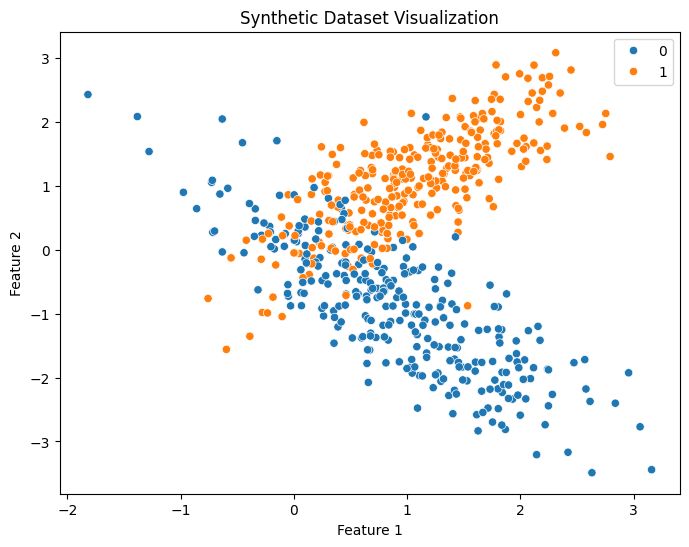

(array([[0.8687836 , 0.8458348 ],
        [0.70852214, 0.71680607],
        [0.63184081, 0.63786494],
        [1.        , 0.00713043],
        [0.57137078, 0.59365177],
        [0.64724682, 0.39166387],
        [0.59314163, 0.5158    ],
        [0.76817506, 0.71198705],
        [0.73929881, 0.71205187],
        [0.7785747 , 0.73713189],
        [0.76954208, 0.09852467],
        [0.75330261, 0.77559518],
        [0.73834859, 0.26750557],
        [0.70124584, 0.2817533 ],
        [0.58787769, 0.62189915],
        [0.68945409, 0.7427068 ],
        [0.75165943, 0.35014697],
        [0.76997243, 0.76733537],
        [0.84727834, 0.0424869 ],
        [0.69099892, 0.37351253],
        [0.75470773, 0.64725479],
        [0.76771441, 0.1365494 ],
        [0.67909218, 0.24814388],
        [0.61985353, 0.69952959],
        [0.58684354, 0.62139883],
        [0.62939279, 0.49171414],
        [0.53438106, 0.42381815],
        [0.71301673, 0.23047867],
        [0.59438389, 0.45252729],
        [0.672

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_curve, auc
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

RANDOM_STATE = 254687
N_SAMPLES = 587
N_FEATURES = 2
N_CLASSES = 2


class SyntheticDataset:
    """A class to generate and preprocess synthetic datasets for classification task."""

    def __init__(self, random_state: int, n_samples: int, n_features: int, n_classes: int):
        """
        Initialize the SyntheticDataset class.

        :param random_state: Seed for random number generation.
        :param n_samples: Number of samples to generate.
        :param n_features: Number of features for the dataset.
        :param n_classess: Number of classes for the target variable.
        """
        self.random_state = random_state
        self.n_samples = n_samples
        self.n_features = n_features
        self.n_classes = n_classes 
        self.X = None
        self.y = None
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None


    def generate_make_classification(self) -> tuple[np.ndarray, np.ndarray]:
        """
        Generate a synthetic dataset using make_classification
        
        :return: A tuple containing the feature matrix (X) and target vector (y)
        """
        self.X, self.y = make_classification(
            n_samples=self.n_samples,
            n_features=self.n_features,
            n_informative=self.n_features,
            n_redundant=0,
            n_clusters_per_class=1, # single-mod means one cluster per class
            random_state=self.random_state
        )
        return self.X, self.y
    
    def generate_make_moons(self) -> tuple[np.ndarray, np.ndarray]:
        """
        Generate a synthetic dataset using make_mmons

        :return: A tuple containing the feature matrix (X) and target vector (y)
        """
        self.X, self.y = make_moons(
            n_samples=self.n_samples,
            random_state=self.random_state,
        )
        return self.X, self.y

    def normalize(self) -> tuple[np.ndarray, np.ndarray]:
        """
        Normalize the feature matrix (X) and target vector(y) to the range [0,1].

        :return: A tuple containing the normalized feature matrix (X) and target vector (y)
 
        Note: 
        Remmber to fit only on training dataset so it means that I use min and max scaler on training dataset and
        then aplly this boudaries for test dataset. 
               """
        if self.X_train is not None and self.X_test is not None:
            min_x, max_x = self.X_train.min(), self.X_train.max() # Min, max taking only from training dataset
            self.X_train = (self.X_train - min_x) / (max_x - min_x)
            self.X_test = (self.X_test - min_x) / (max_x - min_x)

        return self.X_train, self.X_test 


    def visualize(self): 
        """ Visualize the dataset using a scatter plot"""
        if self.X is not None and self.y is not None:
            plt.figure(figsize=(8,6))
            sns.scatterplot(x=self.X[:,0], y=self.X[:,1], hue=self.y)
            plt.title("Synthetic Dataset Visualization")
            plt.xlabel("Feature 1")
            plt.ylabel("Feature 2")
            plt.show()
        else:
            print("Dataset not generated yet. Call generate() first.")


    
    def splitting(self) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Function for splitting datasets into training and test"""
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=RANDOM_STATE)
        return self.X_train, self.X_test, self.y_train, self.y_test

    
dataset = SyntheticDataset(RANDOM_STATE, N_SAMPLES, N_FEATURES, N_CLASSES)
dataset.generate_make_classification() 
dataset.visualize()

# Dividing dataset on a trening set and test set 
dataset.splitting()

# Normalization of datasets 
dataset.normalize()


# 0.1 Implementation of analyzes

In [30]:
class ResultsAnalyzes:
    """ 
    A class to analyze and visualize the results of a binary classification model.

    Parameters:
        target (np.ndarray): The true labels.
        prediction (np.ndarray): The predicted labels.
    """

    def __init__(self, target: np.ndarray, prediction: np.ndarray):
        self.target = target
        self.prediction = prediction
        self._accuracy = None # Private atribute
        self._sensitivity = None
        self._specificity = None
        self._precision = None
        self._false_match_rate = None
        self._false_non_match_rate = None

    def confusion_matrix(self):
        """ Compute and plot the confusion matrix """
        cm = confusion_matrix(self.target, self.prediction)

        # Plot the confusion matrix using Seaborn
        plt.figure(figsize=(6,4))
        sns.heatmap(
            cm, 
            annot=True, # Displays the value in each cell
            fmt="d", # Format the values as integers
            cmap="Blues", # uses a blue color palette 
            cbar=False, # Hide the color bar
            xticklabels=["Predcited 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"]
        )
        
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion matrix")
        plt.show()

    @property 
    def accuracy(self) -> float:
        """ 
        Compute the accuracy of the predictions.
        
        Notes:
            Tells how many samples were well classified from all samples
        """
        return accuracy_score(self.target, self.prediction) 

    @property
    def sensitivity(self) -> float: 
        """ 
        Compute the sensivitty (recall) of the predictions. Sensitivity (Recall) = TP / (TP + FN) 
        
        Notes:
            Tell how many samples were predicted as True Positive from all Acutal Positive
        """
        
        return recall_score(self.target, self.prediction)

    @property
    def specificity(self) -> float: 
        """
        Compute the specificity of the predictions.  Specificity = TN / (TN + FP)

        Notes:
            Tell how many samples were predicted as True Negatives from all Acutal Negative
        """
        
        cm = confusion_matrix(self.target, self.prediction)
        self.tn, self.fp, self.fn, self.tp = cm.ravel() # ravel function in numpy is used to faltten a multi-dimensional array into a 1-dimensional array. It returns a contiguous flattened array, meaning it 
        # collapses the array into a single dimension while maintaining the order of the elements 
        specificity = self.tn / (self.tn + self.fp)
        return specificity
    
    @property
    def balanced_accuracy(self) -> float:
        """
        Compute class imbalance by giving equal weight to both classes.

        Notes:  
         Useful when:
        - Model detects one class better than the other
        - Dataset has unequal class distribution

        !!!! high BA doesn't reveal if the model beats majority-class guessing
        example: in a 90% majority classs, BA = 0.9 could mean the model just predicts the majority that's why we need J score

        **Interpretation:**  
        - 1 = Perfect classifier  
        - 0.5 = Random guessing  
        
        """
        return (self.sensitivity + self.specificity) / 2
    
    @property
    def j_score(self) -> float:
        """
        Measures how much better the model is than random chance. Penalizes models that rely on class imbalance. 

        Notes:
        baseline = 0 means no better than guessing
        J = 0.6 means the model is 60% better than random
        J = -1 means always wrong
        J = 1 means perfect
        """
        return self.sensitivity + self.specificity - 1
    

    @property
    def f1_score(self) -> float:
        """
        Is a critical metric for evaluating classification models, especially when dealing with imbalanced datasets. 
        Penalizes models that ignore the minority class
        Use case: 
        Ideal for fraud detecion, disease screening:
        * In fraud detection: it answers: "Are we catching enough fraud without overwhelming our team?
        * In disease screening "Are we diagnosing patients early without causing unnecessary panic?
        """
        return f1_score(self.target, self.prediction)
    

    @property
    def false_match_rate(self) -> float:
        """
        This metric is critical in biometric systems (e.g., fingerprint, face recognition) and security applications. 
        Mistaking an impostor for a legitimate user.
        
        Notes:
        Lower FMR → Stricter system (fewer impostors accepted, but more legitimate users rejected).
        A bank vault prioritizes low FMR (avoid impostors) → High FNMR is tolerated (owners may retry).
        """
        return self.fp / (self.fp + self.tn)
    

    @property
    def false_non_match_rate(self) -> float:
        """
        This metric is critical in biometric systems (e.g., fingerprint, face recognition) and security applications. 
        Mistaking a legitimate user for an impostor. \
        
        Notes:
        A office door prioritizes low FNMR (avoid frustrating employees) → Higher FMR risk.       
        """
        return self.fn / (self.fn + self.tp)
    

    def show_results(self):
        """ Display the accuracy, sensitivity and specificity of the predictions"""
        #self.accuracy = self._accuracy()
        #self.sensitivity = self._sensitivity()
        #self.specificity = self._specificity()
        print(f"Accuracy: {self.accuracy:.2f}, Sensivity: {self.sensitivity:.2f}, Specifity: {self.specificity:.2f}")

    
    def plot_ROC_curve(self, y_prediction_probability: np.ndarray):
        """
        Plot the Receiver Operaint Characteristic (ROC) curve.
        
        Parameters:
            y_prediction_probability (np.ndarray): The predicted probabilities for the positive class.
        """
        # Compute ORC curve and AUC
        fpr, tpr, thresholds = roc_curve(self.target, y_prediction_probability) # stands for False Positive Rate (1 - Specificity)  and True Positive Rate (Sensitivity)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        plt.figure(figsize=(8,6))
        plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC cruve (AUC = {roc_auc:.2f})")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characterstics Curve")
        plt.legend(loc="lower right")
        plt.show()

        def plot_decision_boundary(self, X: np.ndarray, y: np.ndarray):
            """
            Plot the decision boundary for a trained model.
            
            Parameters:
                X (np.ndarray): The feature matrix of shape (n_samples,n_features)
                y (np.ndarray): The target vector of shape (n_samples,).
            """

            if X.shape[1] != 2:
                raise ValueError("Decision boundary plotting is only supported for 2D feature spaces.")
            
            # Create a grid of points covering the feature space
            x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1 # Frist feature
            y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1 # Second feature

# 1.0 Theory about Diffentiable logic gate network  

In standard boolean logic gates like and, or, xor are discrete. So they output is strictly 0 or 1. That's why we cannot use gradient descent to train them.  

To make logic 'learnable', we relax boolen values {0,1} to continious interval [0, 1].   

For two inputs there are 16 fundamental binary operators which can be formulated using arithmetic operations.  

Instead of choosing one gate (hardcoding an AND gate) the network creates a weighted super-gate. It calculates the results of all 16 operators simultaneously.

$$Output = \sum_{k=1}^{16} w_{i} * Operator_{i}(x,y)$$

Where:
$w_{i}$ : It is a level of activation of k-th gate 

where: 
$\text{Op}_k(x, y)$ : Its is result of 'k'-th logic operator (one of 16) 

so if the network learns w_and = 1 it behaves like and AND gate

# 1.1 Implementation of Logic gate network

In [ ]:
# Ensure reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

class DifferentiableLogicGate(nn.Module):
    """
    A single Logic Gate Unit that learns to be one of the 16 binary operators.
    
    It takes pairs of inputs (x, y) and computes a weighted sum of all 16 
    possible logic outcomes. The weights are learned via Softmax.
    """
    def __init__(self, temperature: float = 1.0):
        super().__init__()
        self.temperature = temperature
        
        # Learnable weights for the 16 gates. 
        # Initialized to near-zero (random) to start with a balanced mixture.
        self.weights = nn.Parameter(torch.randn(16) * 0.1)
        
        # Names for interpretation
        self.gate_names = [
            "FALSE", "AND", "A_and_notB", "A", 
            "notA_and_B", "B", "XOR", "OR", 
            "NOR", "XNOR", "notB", "A_or_notB", 
            "notA", "notA_or_B", "NAND", "TRUE"
        ]

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (Tensor): Input A, shape (batch, N)
            y (Tensor): Input B, shape (batch, N)
            
        Returns:
            Tensor: Output of logic operation, shape (batch, N)
        """
        # Compute all 16 operators (T-Norm / Product Logic) using probabilistic formulation where x, y in [0, 1]
        xy = x * y
        
        # Stack all 16 results: Shape (batch, N, 16)
        gates = torch.stack([
            torch.zeros_like(x),      # 0: FALSE
            xy,                       # 1: AND
            x - xy,                   # 2: A and !B
            x,                        # 3: A
            y - xy,                   # 4: !A and B
            y,                        # 5: B
            x + y - 2 * xy,           # 6: XOR
            x + y - xy,               # 7: OR
            1 - (x + y - xy),         # 8: NOR (1 - OR)
            1 - (x + y - 2 * xy),     # 9: XNOR (1 - XOR)
            1 - y,                    # 10: !B
            1 - (y - xy),             # 11: A or !B
            1 - x,                    # 12: !A
            1 - (x - xy),             # 13: !A or B
            1 - xy,                   # 14: NAND
            torch.ones_like(x)        # 15: TRUE
        ], dim=-1)
        
        # Compute softmax weights shape: (16) -> (1, 1, 16) for broadcasting
        gate_probs = torch.softmax(self.weights / self.temperature, dim=0)
        gate_probs = gate_probs.view(1, 1, -1)
        
        # Weighted sum dot products sum ((Batch, N, 16) * (1, 1, 16)) -> (batch, N)
        output = torch.sum(gates * gate_probs, dim=-1)
        
        return output

class DeepLogicLayer(nn.Module):
    """
    A Layer that projects inputs into pairs and applies logic gates.
    """
    def __init__(self, in_features: int, out_features: int, temperature: float = 1.0):
        super().__init__()
        
        # We need 2 * out_features inputs to feed 'out_features' binary gates so we  can use a Linear layer to learn how to mix/pair the inputs.
        self.projection = nn.Linear(in_features, out_features * 2)
        
        # The logic gate mechanism
        self.logic_gate = DifferentiableLogicGate(temperature)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Project inputs: (Batch, In) -> (Batch, Out * 2)
        mixed = torch.sigmoid(self.projection(x)) # Sigmoid ensures [0,1] range for logic
        
        # Split into pairs for the binary gates
        # chunk(2) splits tensor into two chunks along dim 1
        input_a, input_b = torch.chunk(mixed, chunks=2, dim=1)
        
        # Apply Logic
        return self.logic_gate(input_a, input_b)


class DeepLogicNetwork(nn.Module):
    """
    The main model: A Stack of Logic Layers.
    """
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        
        # Layer 1: Expand inputs into logic space
        self.layer1 = DeepLogicLayer(input_dim, hidden_dim)
        
        # Layer 2: Deep reasoning
        self.layer2 = DeepLogicLayer(hidden_dim, hidden_dim)
        
        # Output Layer: Reduce to class probability (1 output for binary class)
        # We assume binary classification 
        self.output_layer = DeepLogicLayer(hidden_dim, output_dim)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.output_layer(x)
        return x # Returns raw [0, 1] probability



def train_model(model, X_train, y_train, epochs=500, lr=0.01):
    """Standard PyTorch training loop."""
    
    # Convert to Tensors
    # Ensure inputs are strictly [0, 1] for logic stability
    X_tensor = torch.FloatTensor(X_train)
    y_tensor = torch.FloatTensor(y_train).view(-1, 1) # Shape (N, 1)
    
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss() 
    
    losses = []
    
    model.train()
    for epoch in range(epochs):
        
        # Temperature decreasing 
        # Start at 5.0 (Fuzzy) and decay to 0.1 (Crisp)
        current_temp = max(0.1, 5.0 * (0.99 ** epoch))
        
        # Update temp in all layers
        for module in model.modules():
            if hasattr(module, 'temperature'):
                module.temperature = current_temp
                
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            
            # Clamp output to avoid log(0) error in BCELoss
            outputs = torch.clamp(outputs, 1e-7, 1.0 - 1e-7)
            
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Temp: {current_temp:.2f}")
    return losses



# 2. Initialization and testing on blops

Training PyTorch Logic Network...
Epoch 0 | Loss: 0.6931 | Temp: 5.00
Epoch 50 | Loss: 0.6832 | Temp: 3.03
Epoch 100 | Loss: 0.6861 | Temp: 1.83
Epoch 150 | Loss: 0.6886 | Temp: 1.11

Final Test Accuracy: 0.8390


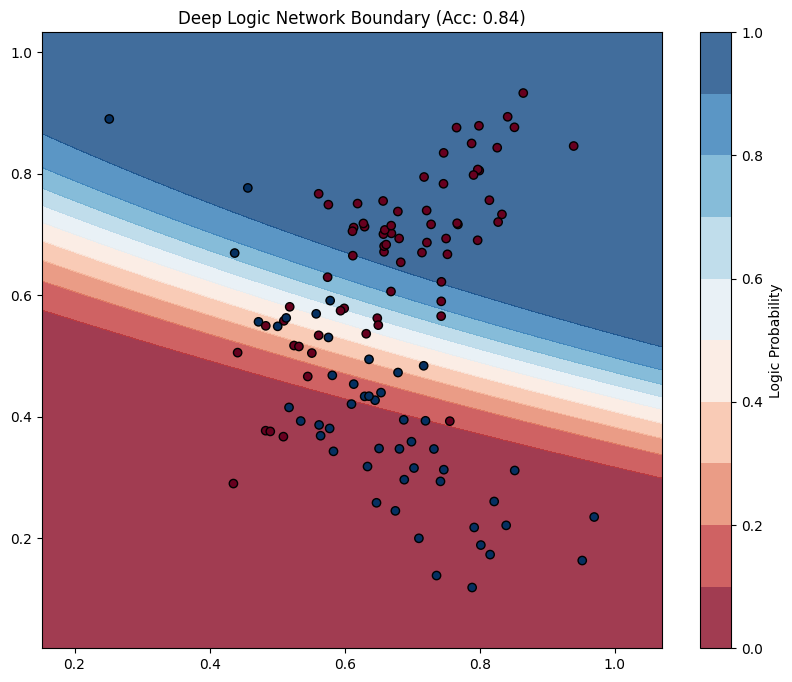


--- Learned Logic in Final Layer ---
notB           : 0.4434
A              : 0.3200
A_and_notB     : 0.1007


In [32]:
# Initialization of model
model = DeepLogicNetwork(input_dim=2, hidden_dim=16, output_dim=1)

# Traininig..
print("Training PyTorch Logic Network...")
losses = train_model(model, dataset.X_train, dataset.y_train, epochs=200, lr=0.01)

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_prob = model(torch.FloatTensor(dataset.X_test)).numpy()
    y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(dataset.y_test, y_pred)
print(f"\nFinal Test Accuracy: {acc:.4f}")


# Visualization of decision boundary
def plot_torch_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    
    with torch.no_grad():
        Z = model(grid).numpy()
    
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 11), cmap="RdBu", alpha=0.8)
    plt.colorbar(label="Logic Probability")
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap="RdBu_r")
    plt.title(f"Deep Logic Network Boundary (Acc: {acc:.2f})")
    plt.show()

plot_torch_boundary(model, dataset.X_test, dataset.y_test)

# Interpretation
# Let's peek at what logic the output layer learned
output_gate_weights = model.output_layer.logic_gate.weights
probs = torch.softmax(output_gate_weights, dim=0).detach().numpy()
names = model.output_layer.logic_gate.gate_names

print("\n--- Learned Logic in Final Layer ---")
indices = np.argsort(probs)[::-1]
for i in indices[:3]: # Top 3 gates
    print(f"{names[i]:<15}: {probs[i]:.4f}")

# 2.1. Testing on moons

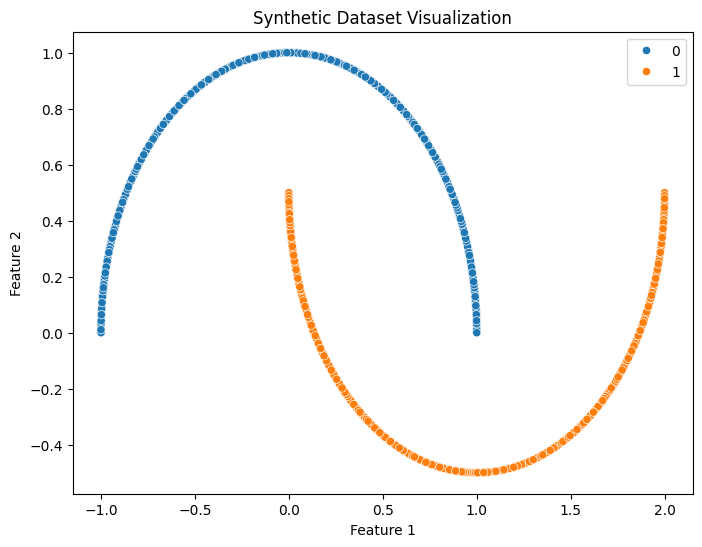

Training PyTorch Logic Network...
Epoch 0 | Loss: 0.6938 | Temp: 5.00
Epoch 50 | Loss: 0.6962 | Temp: 3.03
Epoch 100 | Loss: 0.4176 | Temp: 1.83
Epoch 150 | Loss: 0.3072 | Temp: 1.11

Final Test Accuracy: 0.9661


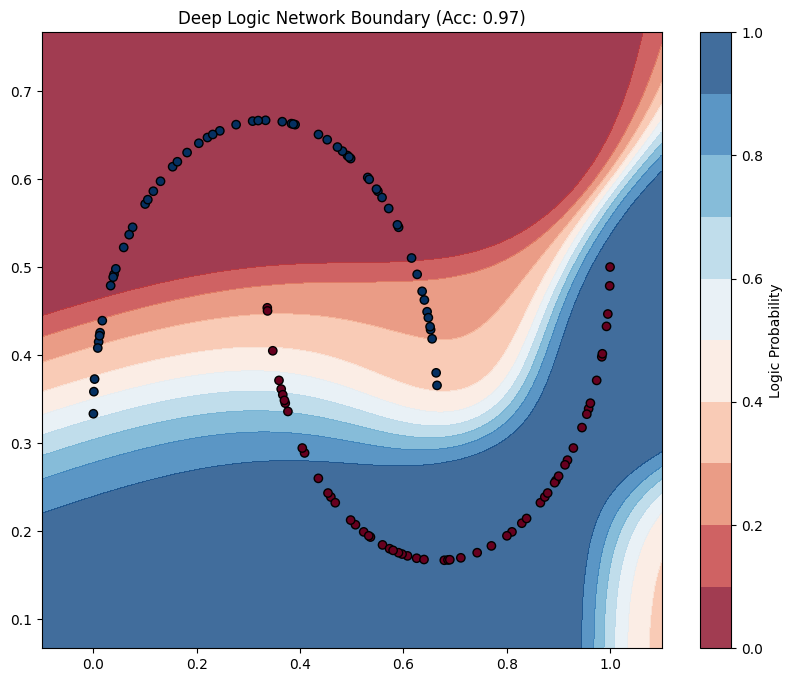


--- Learned Logic in Final Layer ---
notA           : 0.5985
B              : 0.3010
notA_and_B     : 0.0728


In [33]:
dataset_moons = SyntheticDataset(RANDOM_STATE, N_SAMPLES, N_FEATURES, N_CLASSES)
dataset_moons.generate_make_moons() 
dataset_moons.visualize()

# Dividing dataset on a trening set and test set 
dataset_moons.splitting()

# Normalization of datasets 
dataset_moons.normalize()

model = DeepLogicNetwork(input_dim=2, hidden_dim=16, output_dim=1)

# 3. Train
print("Training PyTorch Logic Network...")
losses = train_model(model, dataset_moons.X_train, dataset_moons.y_train, epochs=200, lr=0.01)

# 4. Evaluation
model.eval()
with torch.no_grad():
    y_pred_prob = model(torch.FloatTensor(dataset_moons.X_test)).numpy()
    y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(dataset_moons.y_test, y_pred)
print(f"\nFinal Test Accuracy: {acc:.4f}")

plot_torch_boundary(model, dataset_moons.X_test, dataset_moons.y_test)


output_gate_weights = model.output_layer.logic_gate.weights
probs = torch.softmax(output_gate_weights, dim=0).detach().numpy()
names = model.output_layer.logic_gate.gate_names

print("\n--- Learned Logic in Final Layer ---")
indices = np.argsort(probs)[::-1]
for i in indices[:3]: # Top 3 gates
    print(f"{names[i]:<15}: {probs[i]:.4f}")